<a href="https://colab.research.google.com/github/AbdulWahabSidiqui/portfolio-projects/blob/main/Analyse%20Death%20Involving%20Police/Fatal_Force_Advanced_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fatal Force — Advanced Analysis of Police Killings in the United States

## Project Overview

This project explores data on fatal police shootings in the United States using data collected by The Washington Post.

The original analysis focused on exploring patterns in police killings across factors such as race, gender, age, location, armed status, mental illness, and time.

For this upgraded version, I will build upon that analysis by adding deeper statistical analysis and more interactive visualizations to better understand the patterns and trends in the data.

### Objectives

- Explore trends in police killings over time.
- Examine demographic patterns among people killed by police.
- Compare killings across states and cities.
- Investigate relationships between police killings and factors such as race, poverty, and education.
- Create clear and interactive visualizations.
- Present the findings in a portfolio-ready format.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Google Colab
- GitHub

# Part 1 — Original Course Analysis

The following sections contain the original analysis completed as part of the Python course.

This analysis forms the foundation for the advanced analysis added later in the project.

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [57]:
%pip install --upgrade plotly

## Import Statements

In [58]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from IPython.display import display, HTML

## Notebook Presentation

In [59]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [60]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [61]:
print(df_fatalities.shape)
print(df_hh_income.shape)
print(df_pct_completed_hs.shape)
print(df_pct_poverty.shape)
print(df_share_race_city.shape)

(2535, 14)
(29322, 3)
(29329, 3)
(29329, 3)
(29268, 7)


In [62]:
print(df_fatalities.head)
print(df_hh_income.head)
print(df_pct_completed_hs.head)
print(df_pct_poverty.head)
print(df_share_race_city.head)

<bound method NDFrame.head of         id                name      date   manner_of_death       armed   age  \
0        3          Tim Elliot  02/01/15              shot         gun 53.00   
1        4    Lewis Lee Lembke  02/01/15              shot         gun 47.00   
2        5  John Paul Quintero  03/01/15  shot and Tasered     unarmed 23.00   
3        8     Matthew Hoffman  04/01/15              shot  toy weapon 32.00   
4        9   Michael Rodriguez  04/01/15              shot    nail gun 39.00   
...    ...                 ...       ...               ...         ...   ...   
2530  2822    Rodney E. Jacobs  28/07/17              shot         gun 31.00   
2531  2813               TK TK  28/07/17              shot     vehicle   NaN   
2532  2818  Dennis W. Robinson  29/07/17              shot         gun 48.00   
2533  2817       Isaiah Tucker  31/07/17              shot     vehicle 28.00   
2534  2815        Dwayne Jeune  31/07/17              shot       knife 32.00   

     gend

In [63]:
print(df_fatalities.isna().sum())
print(df_hh_income.isna().sum())
print(df_pct_completed_hs.isna().sum())
print(df_pct_poverty.isna().sum())
print(df_share_race_city.isna().sum())

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64
Geographic Area     0
City                0
Median Income      51
dtype: int64
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64
Geographic Area    0
City               0
poverty_rate       0
dtype: int64
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [64]:
df_hh_income = df_hh_income.fillna(0)
df_pct_poverty = df_pct_poverty.fillna(0)
df_pct_completed_hs = df_pct_completed_hs.fillna(0)
df_share_race_city = df_share_race_city.fillna(0)
df_fatalities = df_fatalities.fillna(0)

# Chart the Poverty Rate in each US State


In [65]:
df_pct_poverty["poverty_rate"] = pd.to_numeric(df_pct_poverty["poverty_rate"],errors="coerce")
poverty_by_state = (
    df_pct_poverty
    .groupby("Geographic Area")["poverty_rate"]
    .mean()
    .reset_index()
    .sort_values("poverty_rate", ascending=False)
)

In [66]:
fig = px.bar(
    poverty_by_state,
    x = "poverty_rate",
    y = "Geographic Area",
    title = "Poverty Rate by US State",
    labels = {
        "Geographic Area": "State",
        "poverty_rate": "Average Poverty Rate (%)"
    })
fig.update_layout(yaxis=dict(categoryorder="total ascending"))
fig.show()

<!doctype html>

In [67]:
print(f"Highest Poverty Rate: {poverty_by_state.iloc[0]}")
print(f"Lowest Poverty Rate: {poverty_by_state.iloc[-1]}")

Highest Poverty Rate: Geographic Area      MS
poverty_rate      26.88
Name: 25, dtype: object
Lowest Poverty Rate: Geographic Area     NJ
poverty_rate      8.19
Name: 31, dtype: object


# Chart the High School Graduation Rate by US State



In [68]:
df_pct_completed_hs["percent_completed_hs"] = pd.to_numeric(df_pct_completed_hs["percent_completed_hs"],errors="coerce")
graduation_by_state = (
    df_pct_completed_hs
    .groupby("Geographic Area")["percent_completed_hs"]
    .mean()
    .reset_index()
    .sort_values("percent_completed_hs", ascending=True)
)

In [69]:
fig = px.bar(
    graduation_by_state,
    x = "percent_completed_hs",
    y = "Geographic Area",
    title = "Poverty Rate by US State",
    labels = {
        "Geographic Area": "State",
        "percent_completed_hs": "High School Graduation Rate (%)"
    })
fig.show()

<!doctype html>

In [70]:
lowest = graduation_by_state.iloc[0]
highest = graduation_by_state.iloc[-1]
print(
    f"Lowest graduation rate: "
    f"{lowest['Geographic Area']} ({lowest['percent_completed_hs']:.2f}%)"
)

print(
    f"Highest graduation rate: "
    f"{highest['Geographic Area']} ({highest['percent_completed_hs']:.2f}%)"
)

Lowest graduation rate: TX (75.69%)
Highest graduation rate: MA (92.40%)


# Visualise the Relationship between Poverty Rates and High School Graduation Rates



In [71]:
combined = pd.merge(
    poverty_by_state,
    graduation_by_state,
    on="Geographic Area"
)
combined.head()

,Geographic Area,poverty_rate,percent_completed_hs
0,MS,26.88,78.47
1,AZ,25.67,80.47
2,GA,23.78,79.01
3,NM,23.08,80.98
4,AR,22.96,79.95


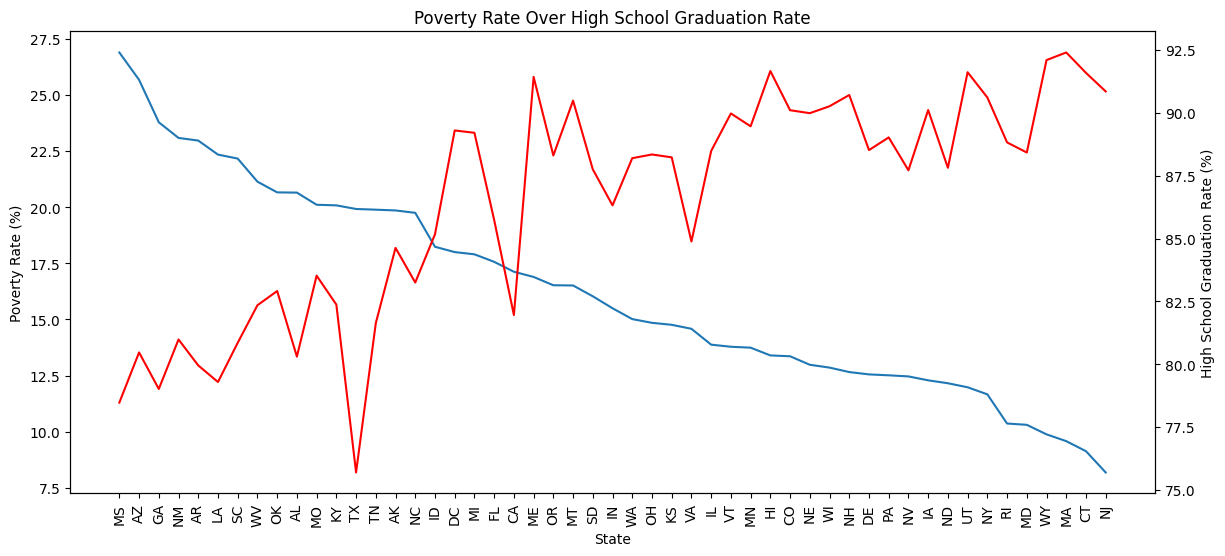

In [72]:
fig,ax1 = plt.subplots(figsize=(14,6))
ax1.plot(
    combined["Geographic Area"],
    combined["poverty_rate"],
    label= "Poverty Rate"
  )
ax1.set_xlabel("State")
ax1.set_ylabel("Poverty Rate (%)")
ax1.tick_params(axis="x",rotation=90)
ax2 = ax1.twinx()
ax2.plot(
    combined["Geographic Area"],
    combined["percent_completed_hs"],
    label= "Graduation Rate",
    color="red"
  )
ax2.set_ylabel("High School Graduation Rate (%)")
plt.title("Poverty Rate Over High School Graduation Rate")
plt.show()

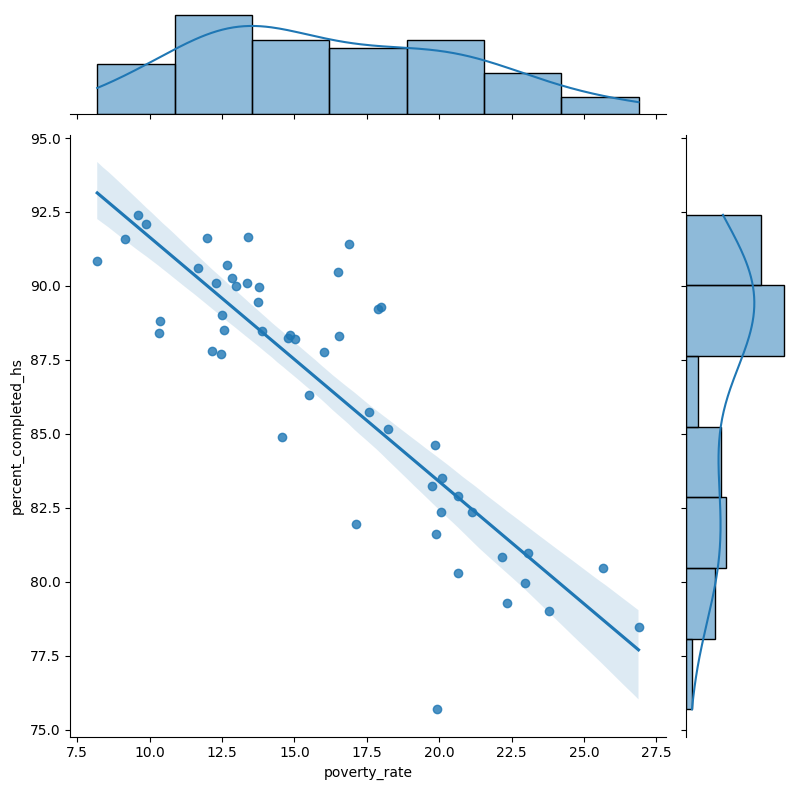

In [73]:
sns.jointplot(
    data=combined,
    x="poverty_rate",
    y="percent_completed_hs",
    kind="reg",
    height=8
)
plt.show()

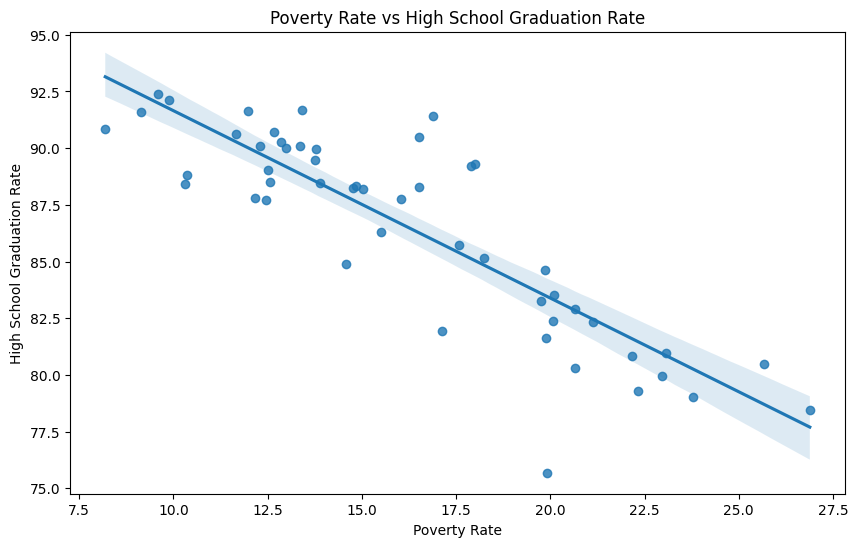

In [74]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=combined,
    x="poverty_rate",
    y="percent_completed_hs"
)
plt.title("Poverty Rate vs High School Graduation Rate")
plt.xlabel("Poverty Rate")
plt.ylabel("High School Graduation Rate")
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State


In [75]:
race_columns = [
          'share_white',
         'share_black',
         'share_native_american',
         'share_asian',
         'share_hispanic'
]
for columns in race_columns:
  df_share_race_city[columns] = pd.to_numeric(df_share_race_city[columns],errors="coerce")
race_by_state=(
    df_share_race_city
    .groupby("Geographic area")[race_columns]
    .mean()
    .reset_index()
)

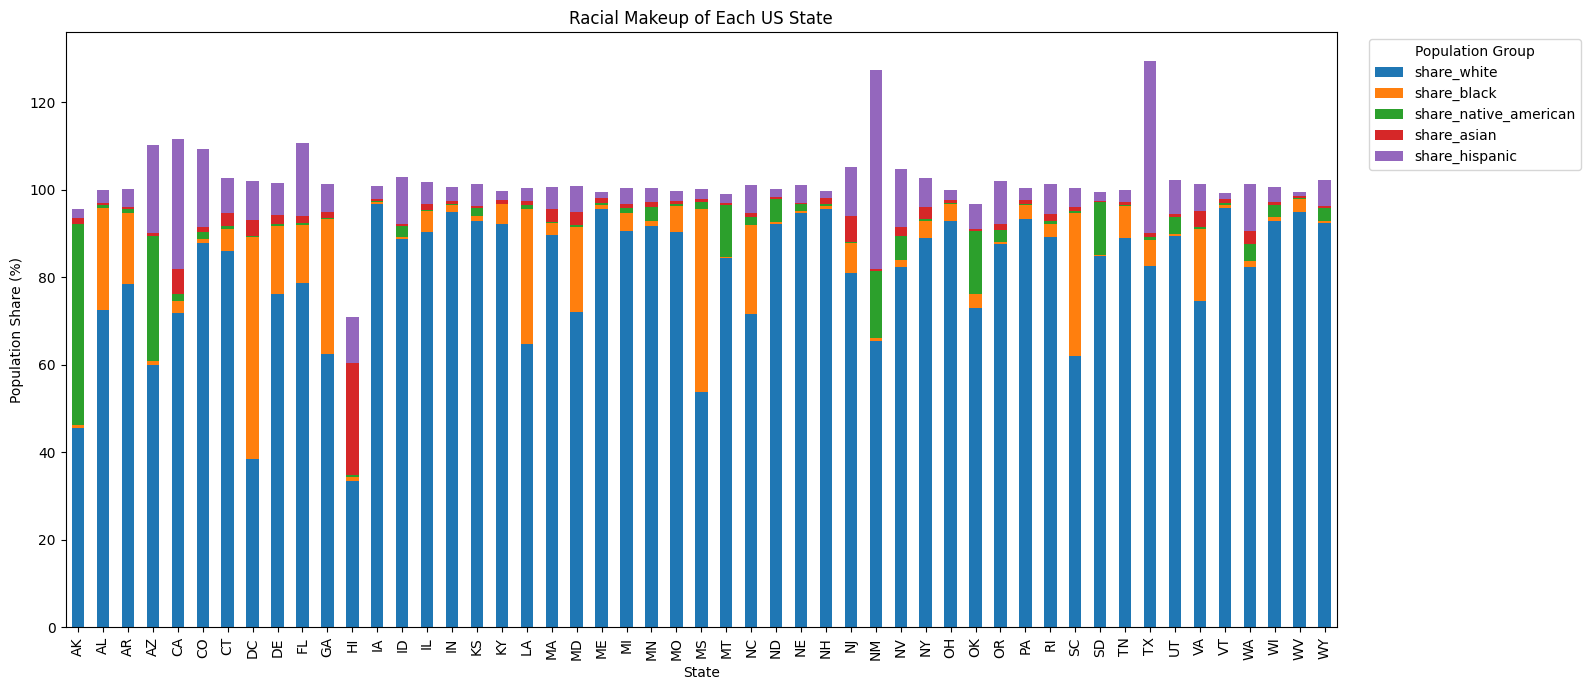

In [76]:
race_by_state.set_index("Geographic area").plot(
    kind="bar",
    stacked=True,
    figsize=(16,7)
)
plt.title("Racial Makeup of Each US State")
plt.xlabel("State")
plt.ylabel("Population Share (%)")
plt.xticks(rotation=90)
plt.legend(
    title="Population Group",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

# Create Donut Chart by of People Killed by Race



In [77]:
race_counts = df_fatalities["race"].value_counts()

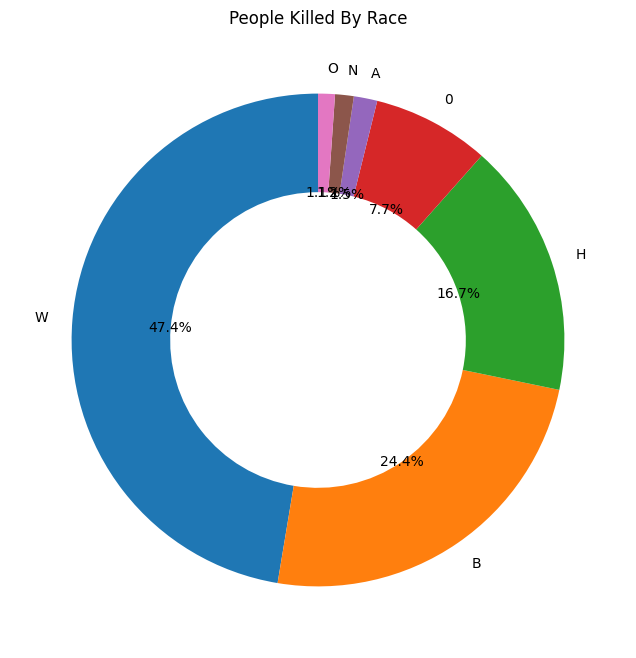

In [78]:
plt.figure(figsize=(8,8))
plt.pie(
    race_counts,
    labels=race_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)
plt.title("People Killed By Race")
plt.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women



In [79]:
gender_counts = df_fatalities["gender"].value_counts()
fig = px.bar(
    x=gender_counts.index,
    y=gender_counts.values,
    title="Total Number of Deaths By Gender",
    labels={
        "x":"Gender",
        "y":"Number of Deaths"
    }
)
fig.show()

<!doctype html>

# Create a Box Plot Showing the Age and Manner of Death



In [80]:
fig = px.box(
    df_fatalities,
    x="manner_of_death",
    y="age",
    color="gender",
    title="Age and Manner of Death by Gender"
)
fig.show()

<!doctype html>

# Were People Armed?



In [81]:
armed_counts = df_fatalities["armed"].value_counts()

In [82]:
fig = px.bar(
    x=armed_counts.index,
    y=armed_counts.values,
    title="Weapons carried by People Killed by Police",
    labels={
        "x":"Weapon",
        "y":"Number of Deaths"
    }
)
fig.show()

<!doctype html>

# How Old Were the People Killed?

In [83]:
under_25= (df_fatalities["age"] < 25).sum()
total= df_fatalities["age"].notna().sum()
percentage_under_25= (under_25/total)*100

print(f"{percentage_under_25:.2f}% of people killed were under 25 years old.")

20.79% of people killed were under 25 years old.


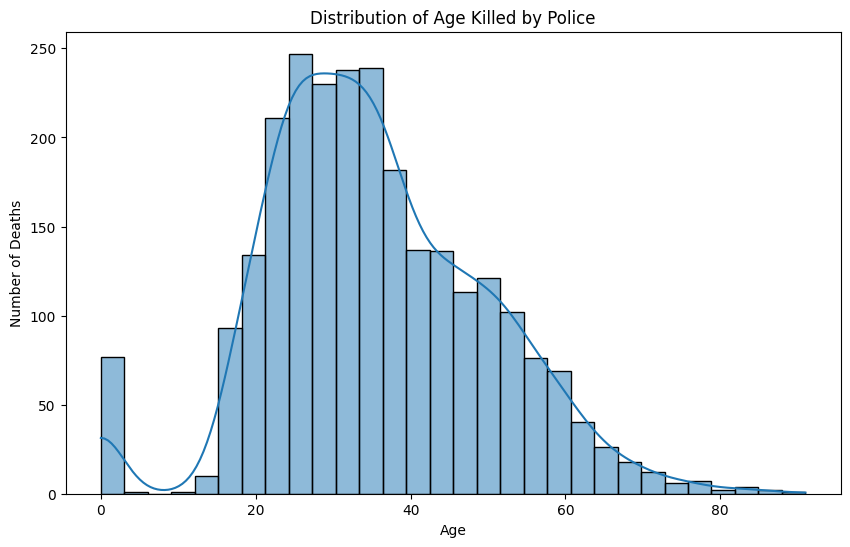

In [84]:
plt.figure(figsize=(10,6))
sns.histplot(
    df_fatalities["age"].dropna(),
    kde=True,
    bins=30
)
plt.title("Distribution of Age Killed by Police")
plt.xlabel("Age")
plt.ylabel("Number of Deaths")
plt.show()

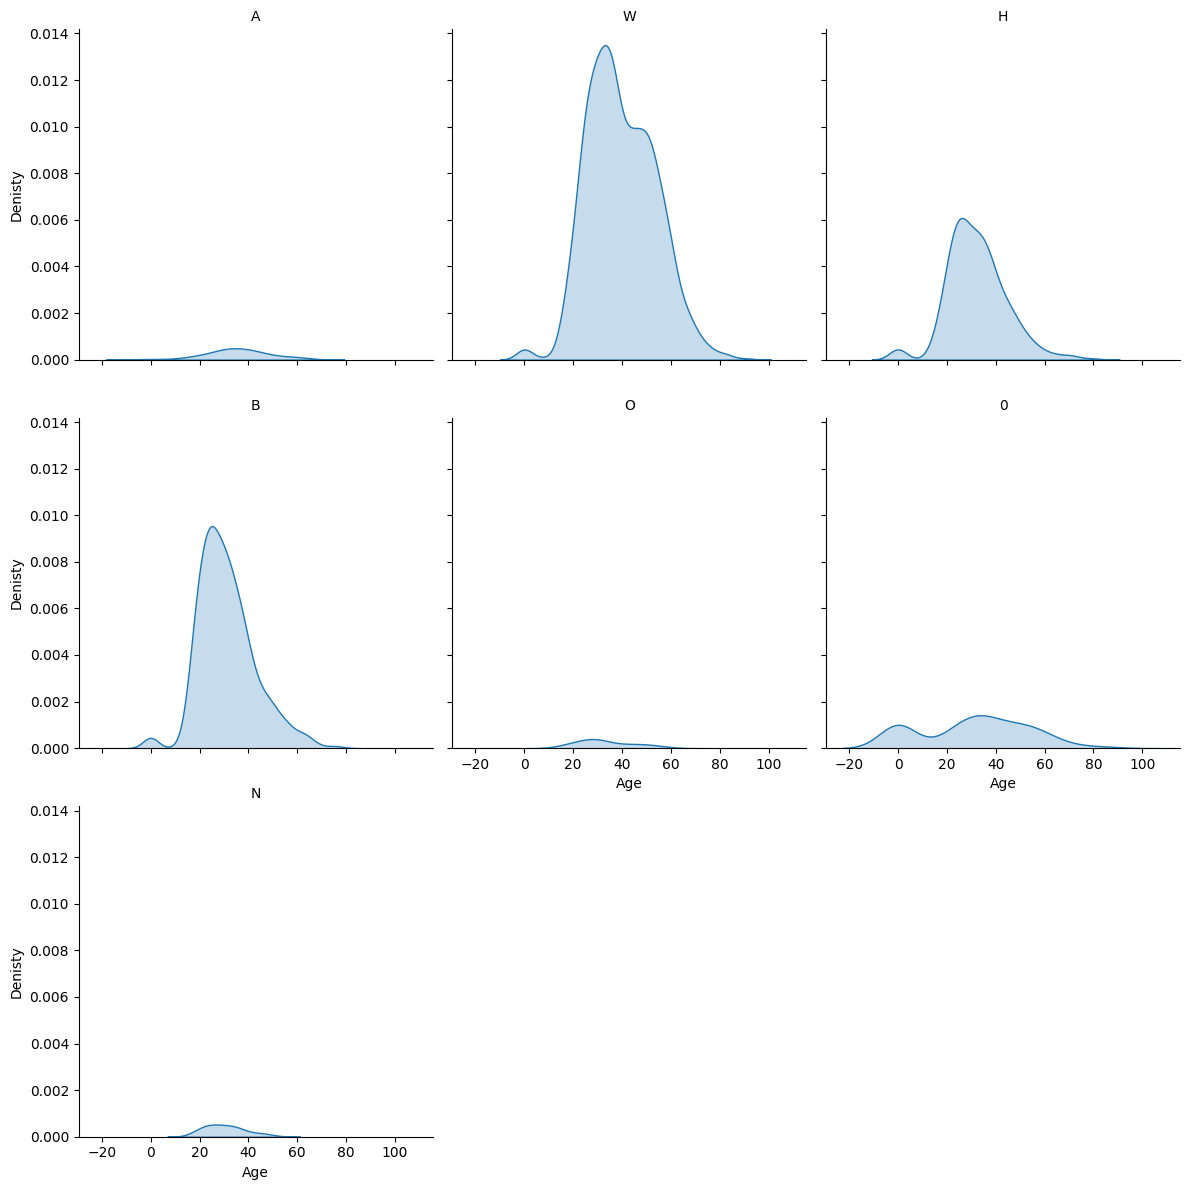

In [85]:
g = sns.displot(
  data=df_fatalities,
  x="age",
  col="race",
  kind="kde",
  col_wrap=3,
  height=4,
  fill=True
)
g.set_axis_labels("Age","Denisty")
g.set_titles("{col_name}")
plt.show()

# Race of People Killed


In [86]:
race_counts = df_fatalities["race"].value_counts()
fig=px.bar(
    x=race_counts.index,
    y=race_counts.values,
    title="Total Number of People Killed By Race",
    labels={
        "x":"Race",
        "y":"Number of Deaths"
    }
)
fig.show()

<!doctype html>

# Mental Illness and Police Killings


In [87]:
mental_illness = df_fatalities["signs_of_mental_illness"].value_counts()

In [88]:
fig = px.bar(
    x=mental_illness.index,
    y=mental_illness.values,
    title="Police Killings by Sign of Mental Illness",
    labels={
        "x":"Sign of Mental Illness",
        "y":"Number of People"
    }
)
fig.show()

<!doctype html>

# In Which Cities Do the Most Police Killings Take Place?



In [89]:
city_counts = df_fatalities["city"].value_counts().head(10).sort_values()

In [90]:
fig = px.bar(
    x=city_counts.values,
    y=city_counts.index,
    orientation="h",
    title="Top 10 Cities with most Police Killings",
    labels={
        "x":"Number of Police Killings",
        "y":"City"
    }
)
fig.show()

<!doctype html>

# Rate of Death by Race



In [91]:
top_10_cities = df_fatalities["city"].value_counts().head(10)
top_cities_data = df_fatalities[df_fatalities["city"].isin(top_10_cities.index)]
race_city_counts = pd.crosstab(
    top_cities_data["city"],
    top_cities_data["race"]
)
race_city_share = race_city_counts.div(
    race_city_counts.sum(axis=1),
    axis=0
) * 100
race_city_share.round(2)

race,0,A,B,H,N,O,W
city,,,,,,,
Austin,0.00,0.00,16.67,11.11,0.00,0.00,72.22
Chicago,4.00,0.00,84.00,4.00,0.00,0.00,8.00
Columbus,5.26,0.00,57.89,0.00,0.00,5.26,31.58
Houston,3.70,3.70,55.56,22.22,3.70,0.00,11.11
Las Vegas,19.05,0.00,14.29,23.81,0.00,0.00,42.86
Los Angeles,7.69,2.56,25.64,48.72,0.00,0.00,15.38
Miami,5.56,0.00,44.44,33.33,0.00,0.00,16.67
Phoenix,9.68,0.00,6.45,35.48,9.68,0.00,38.71
San Antonio,10.00,0.00,15.00,60.00,0.00,0.00,15.00


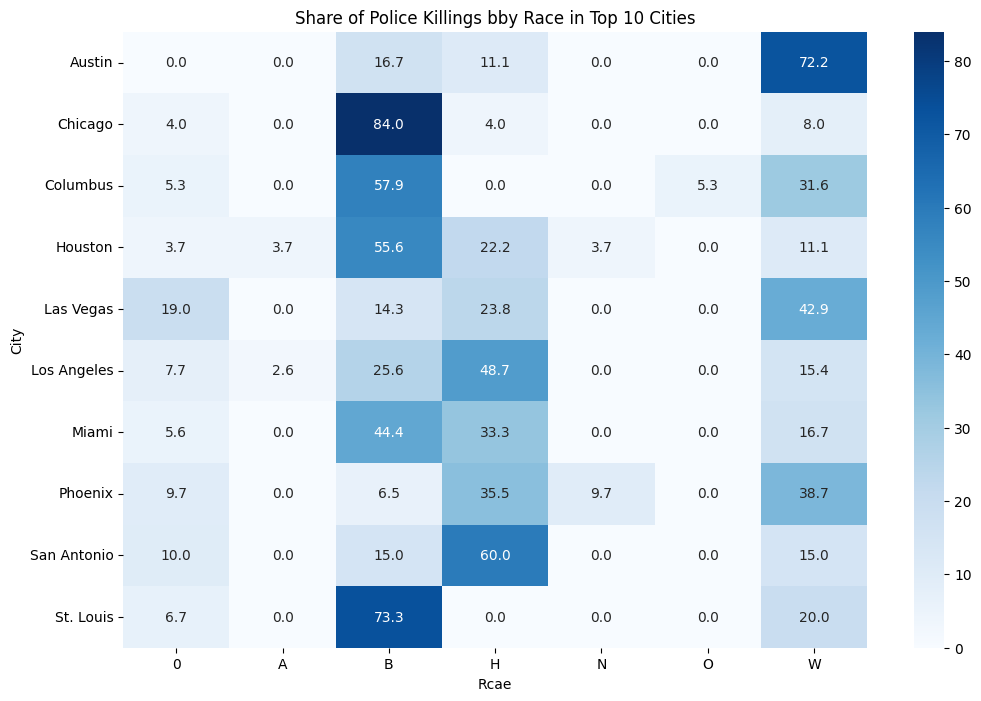

In [92]:
plt.figure(figsize=(12,8))
sns.heatmap(
    race_city_share,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)
plt.title("Share of Police Killings bby Race in Top 10 Cities")
plt.xlabel("Rcae")
plt.ylabel("City")
plt.show()

# Create a Choropleth Map of Police Killings by US State


In [93]:
state_counts = df_fatalities["state"].value_counts().reset_index()
state_counts.columns = ["State","Killings"]

In [94]:
fig = px.choropleth(
    state_counts,
    locations="State",
    locationmode="USA-states",
    color="Killings",
    scope="usa",
    color_continuous_scale="Reds",
    title="Police Killings by US State",
    labels={"Killings":"Number of Police Killings"}
)
fig.show()

<!doctype html>

# Number of Police Killings Over Time



In [95]:
df_fatalities["date"] = pd.to_datetime(df_fatalities["date"])
df_fatalities["year"] = df_fatalities["date"].dt.year

/tmp/ipykernel_578/1683190931.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_fatalities["date"] = pd.to_datetime(df_fatalities["date"])


In [96]:
yearly_killings= df_fatalities["year"].value_counts().sort_index()

In [97]:
fig = px.line(
    x=yearly_killings.index,
    y=yearly_killings.values,
    title="Number of Police Killings Over Time",
    labels={
        "x":"Year",
        "y":"Number of Police Killings"
    }
)
fig.show()

<!doctype html>

# Part 2 — Advanced Analysis

This section builds upon the original course analysis by exploring additional
patterns and trends in the data through deeper analysis and interactive
visualizations.

## Year-over-Year Analysis of Police Killings

In [98]:
yearly_killings = df_fatalities["year"].value_counts().sort_index()

In [99]:
yearly_analysis = yearly_killings.to_frame(name="killings")
yearly_analysis["change"] = yearly_analysis["killings"].diff()
yearly_analysis["percentage_change"] = yearly_analysis["killings"].pct_change() * 100

### Data Insight

The dataset contains 991 police killings in 2015 and 963 in 2016, representing a decrease of 28 cases (2.83%).

The dataset records 581 killings in 2017. However, because the available data only covers part of 2017, the 39.67% decrease compared with 2016 should not be interpreted as a full-year decline.

Therefore, the year-over-year comparison is most meaningful between the complete years 2015 and 2016.

In [100]:
fig = px.line(
    yearly_analysis,
    x = yearly_analysis.index,
    y="killings",
    markers=True,
    title="Police Killings By Year"
)
fig.update_layout(
  xaxis_title="Year",
  yaxis_title="Number of Police Killings"
)
fig.show()

<!doctype html>

## Threat Level and Armed Status

This analysis examines the relationship between the reported threat level and whether a person killed by police was recorded as armed.

In [101]:
def classify_armed_status(value):
  if value == "unarmed":
    return "Unarmed"
  elif value == "undetermined":
    return "Undetermined"
  else:
    return "Armed"

df_fatalities["armed_status"] = df_fatalities["armed"].apply(classify_armed_status)

In [102]:
threat_armed = pd.crosstab(
    df_fatalities["threat_level"],
    df_fatalities["armed_status"]
)

In [103]:
threat_armed_pct = pd.crosstab(
    df_fatalities["threat_level"],
    df_fatalities["armed_status"],
    normalize="index"
) * 100
threat_armed_pct.round(2)

armed_status,Armed,Unarmed,Undetermined
threat_level,,,
attack,94.72,4.03,1.24
other,86.29,10.44,3.26
undetermined,37.97,16.46,45.57


In [104]:
threat_armed_plot = threat_armed_pct.reset_index().melt(
    id_vars="threat_level",
    var_name="armed_status",
    value_name="percentage"
)

fig = px.bar(
    threat_armed_plot,
    x="threat_level",
    y="percentage",
    color="armed_status",
    barmode="group",
    text_auto=".1f",
    title="Armed Status by Reported Threat Level",
    labels={
        "threat_level": "Threat Level",
        "percentage": "Percentage of Cases (%)",
        "armed_status": "Armed Status"
    }
)

fig.update_layout(
    yaxis_range=[0, 100]
)

fig.show()

<!doctype html>

### Data Insight

The analysis shows a strong relationship between the reported threat level and armed status.

Among cases classified as an **attack**, 94.72% involved someone classified as armed, while 4.03% were classified as unarmed.

For cases classified as **other**, 86.29% involved someone classified as armed and 10.44% were unarmed.

The **undetermined** threat-level group shows a different pattern: 45.57% of cases also had an undetermined armed status, while 37.97% were classified as armed.

Overall, cases classified as an attack were much more likely to involve an individual recorded as armed than cases classified as other or undetermined.

These results describe an association in the dataset and do not establish that threat level caused the outcome.

In [105]:
df_fatalities.groupby("year")["body_camera"].mean() * 100

,body_camera
year,
2015,7.47
2016,14.33
2017,10.15


In [106]:
body_camera_by_year = (
    df_fatalities.groupby("year")["body_camera"]
    .mean()
    .mul(100)
    .reset_index(name="percentage")
)

fig = px.line(
    body_camera_by_year,
    x="year",
    y="percentage",
    markers=True,
    text=body_camera_by_year["percentage"].round(2),
    title="Body Camera Presence in Fatal Police Shooting Cases",
    labels={
        "year": "Year",
        "percentage": "Cases with Body Camera (%)"
    }
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    yaxis_range=[0, 20]
)

fig.show()

<!doctype html>

### Data Insight

The percentage of fatal police shooting cases involving a body camera increased from 7.47% in 2015 to 14.33% in 2016. In the available 2017 data, the percentage was 10.15%.

The largest observed increase occurred between 2015 and 2016, when the share of cases involving a body camera almost doubled.

However, the 2017 data covers only part of the year, so the 10.15% figure should not be interpreted as a full-year estimate or as evidence of a sustained decline.

## Gender and Armed Status

In [107]:
gender_armed = pd.crosstab(
    df_fatalities["gender"],
    df_fatalities["armed_status"],
    normalize="index"
) * 100
gender_armed.round(2)

armed_status,Armed,Unarmed,Undetermined
gender,,,
F,87.85,10.28,1.87
M,88.67,6.59,4.74


In [108]:
gender_armed_plot = gender_armed.reset_index().melt(
    id_vars="gender",
    var_name="armed_status",
    value_name="percentage"
)

fig = px.bar(
    gender_armed_plot,
    x="gender",
    y="percentage",
    color="armed_status",
    barmode="group",
    text_auto=".1f",
    title="Armed Status by Gender",
    labels={
        "gender": "Gender",
        "percentage": "Percentage of Cases (%)",
        "armed_status": "Armed Status"
    }
)

fig.update_layout(yaxis_range=[0, 100])

fig.show()

<!doctype html>

### Data Insight

The percentage of cases classified as armed was very similar for females (87.85%) and males (88.67%).

However, female cases had a higher proportion classified as unarmed (10.28%) compared with male cases (6.59%). Male cases had a higher proportion with an undetermined armed status (4.74%) compared with female cases (1.87%).

Overall, the data shows that armed cases made up the large majority of fatal police shooting cases for both genders in this dataset.

These results describe patterns in the dataset and do not establish a causal relationship between gender and armed status.

# Part 3 — Interactive Summary Dashboard

This section brings together key findings from the analysis into an interactive
summary of fatal police shootings recorded in the dataset.

## Key Statistics

In [109]:
total_fatalities = len(df_fatalities)

average_age = df_fatalities["age"].mean()

male_percentage = (
    df_fatalities["gender"].eq("M").mean() * 100
)

body_camera_percentage = (
    df_fatalities["body_camera"].mean() * 100
)

print(f"Total fatalities: {total_fatalities:,}")
print(f"Average age: {average_age:.1f}")
print(f"Male: {male_percentage:.1f}%")
print(f"Body camera present: {body_camera_percentage:.1f}%")

Total fatalities: 2,535
Average age: 35.5
Male: 95.8%
Body camera present: 10.7%


In [110]:
display(HTML(f"""
<div style="display: flex; gap: 15px; margin: 20px 0;">

    <div style="padding: 20px; border: 1px solid #ddd; border-radius: 10px; flex: 1; text-align: center;">
        <h3>Total Fatalities</h3>
        <h1>{total_fatalities:,}</h1>
    </div>

    <div style="padding: 20px; border: 1px solid #ddd; border-radius: 10px; flex: 1; text-align: center;">
        <h3>Average Age</h3>
        <h1>{average_age:.1f}</h1>
    </div>

    <div style="padding: 20px; border: 1px solid #ddd; border-radius: 10px; flex: 1; text-align: center;">
        <h3>Male</h3>
        <h1>{male_percentage:.1f}%</h1>
    </div>

    <div style="padding: 20px; border: 1px solid #ddd; border-radius: 10px; flex: 1; text-align: center;">
        <h3>Body Camera</h3>
        <h1>{body_camera_percentage:.1f}%</h1>
    </div>

</div>
"""))

### Dashboard Summary

The dataset contains 2,535 recorded fatal police shootings. The average age of the people in the dataset was 35.5 years, and 95.8% of cases involved males. A body camera was recorded as present in 10.7% of cases.

These statistics provide a high-level overview of the dataset before examining the individual patterns explored throughout the project.

## Final Conclusions

This project explored patterns in fatal police shootings using demographic,
behavioral, geographic, and temporal information.

The original analysis identified important patterns in the data, while the
advanced analysis extended the project by examining relationships between
multiple variables and presenting several findings through interactive
visualizations.

Some key observations from the advanced analysis include:

- The number of recorded fatalities decreased slightly from 2015 to 2016.
- The relationship between threat level and armed status was particularly
  noticeable, with cases classified as an attack having the highest proportion
  of armed individuals.
- Body-camera presence increased from 7.47% in 2015 to 14.33% in 2016, while
  the available 2017 data showed 10.15%.
- Armed cases represented the large majority of cases for both males and
  females.
- The dataset contained 2,535 fatalities, with an average age of 35.5 years
  and 95.8% of cases involving males.

### Limitations

The dataset covers only part of 2017, so comparisons involving 2017 should
not be interpreted as full-year trends.

In addition, the analysis describes patterns and associations within the
dataset. It does not establish causal relationships between the variables.

### What I Learned

This project strengthened my ability to clean and explore real-world datasets,
combine variables to uncover deeper patterns, calculate meaningful
percentages, and communicate findings through visualizations.

The advanced analysis also helped me move beyond answering predefined
questions and develop my own analytical questions based on the available
data.